In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#import squidpy as sq
from glob import glob

In [2]:
adata = sc.read_h5ad('/lustre/groups/ml01/workspace/hpca/hpca_downstream/label_transfer_spatial/TACCO/spatialpancreas_tacco_healthy/h5ad/S1_annotated_l0.h5ad')

In [3]:
adata_paths = glob('/lustre/groups/ml01/workspace/hpca/hpca_downstream/label_transfer_spatial/TACCO/spatialpancreas_tacco_healthy/h5ad/*_annotated_l0.h5ad')

In [4]:
adata_dissoc = sc.read_h5ad('/lustre/groups/ml01/workspace/hpca/hpca_downstream/2026_final_object_healthy_hierarchy.h5ad')

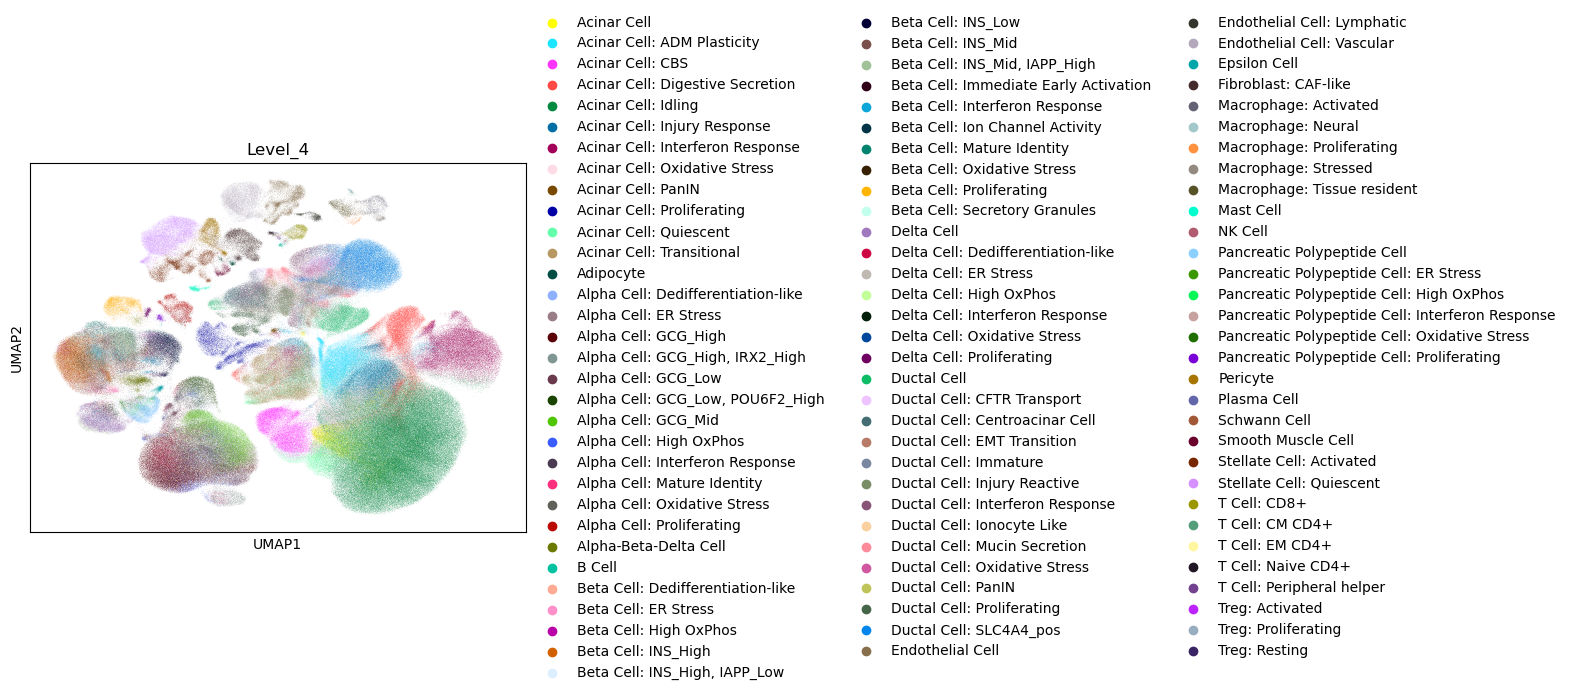

In [10]:
sc.pl.umap(adata_dissoc, color='Level_4')

In [11]:
adata_dissoc[adata_dissoc.obs.Level_4 == 'Alpha-Beta-Delta Cell']

View of AnnData object with n_obs × n_vars = 4898 × 24600
    obs: 'barcode', 'Dataset', 'ID', 'sample_id', 'donor_id', 'alignment_software', 'assay_ontology_term_id', 'institute', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'Manual_Annotation', 'cell_enrichment', 'condition', 'celltype_all', 'manner_of_death', 'reference_genome', 'sample_collection_method', 'sample_source', 'sampled_site_condition', 'samples', 'sex', 'sex--cell_ontology_term_id', 'suspension_type', 'technology', 'tissue_type', 'assay', 'tissue', 'organism', 'disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covar_split_donor_id', 'batch_covariate', 'info_batch_covariate_split', 'doublet_score', 'predicted_doublet', 'n_genes', 'total_counts', 'total_counts_mito', 'total_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mito', 'log1p_total_counts_ribo', 'n_genes_by_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_i

In [12]:
pd.crosstab(adata.obs.cell_type_coarse, adata.obs.predicted_Level_3).T

cell_type_coarse,Acinar,Alpha,Beta,Ductal,Endocrine,Endothelial,Fibroblasts,Immune,Mast
predicted_Level_3,,,,,,,,,
Acinar Cell,62862,0,3,10353,386,1764,5196,1111,66
Adipocyte,6,0,0,34,0,1,40,2,0
Alpha Cell,170,1920,597,1644,346,16,171,69,11
Beta Cell,73,731,3232,119,318,8,94,11,7
Delta Cell,29,34,115,132,6,2,19,11,7
Ductal Cell,623,0,0,8114,4,2,17,42,4
Endothelial Cell,72,25,2,51,1,714,282,55,44
Epsilon Cell,18,0,0,40,0,0,8,1,0
Fibroblast,56,0,0,29,0,15,525,48,7


Label transfer accuracy (predicted_Level_3 -> cell_type_coarse): 84.9%
  59,712 / 70,343 cells correct (10,631 misclassified)


predicted,Acinar,Alpha,Beta,Ductal,Endocrine,Endothelial,Fibroblasts,Immune,Mast
true,,,,,,,,,
Acinar,51297,6,7,89,1,12,27,36,0
Alpha,0,1313,380,0,117,5,14,0,0
Beta,0,285,2748,0,94,0,0,0,0
Ductal,3582,367,9,2412,8,6,81,13,0
Endocrine,97,138,170,0,3,0,0,0,0
Endothelial,702,0,1,0,0,277,11,1,0
Fibroblasts,3357,43,28,1,5,153,1197,95,2
Immune,462,14,1,1,0,6,60,447,1
Mast,16,0,0,0,0,11,77,39,18


              precision    recall  f1-score   support

      Acinar       0.86      1.00      0.92     51475
       Alpha       0.61      0.72      0.66      1829
        Beta       0.82      0.88      0.85      3127
      Ductal       0.96      0.37      0.54      6478
   Endocrine       0.01      0.01      0.01       408
 Endothelial       0.59      0.28      0.38       992
 Fibroblasts       0.82      0.25      0.38      4881
      Immune       0.71      0.45      0.55       992
        Mast       0.86      0.11      0.20       161

    accuracy                           0.85     70343
   macro avg       0.69      0.45      0.50     70343
weighted avg       0.85      0.85      0.82     70343



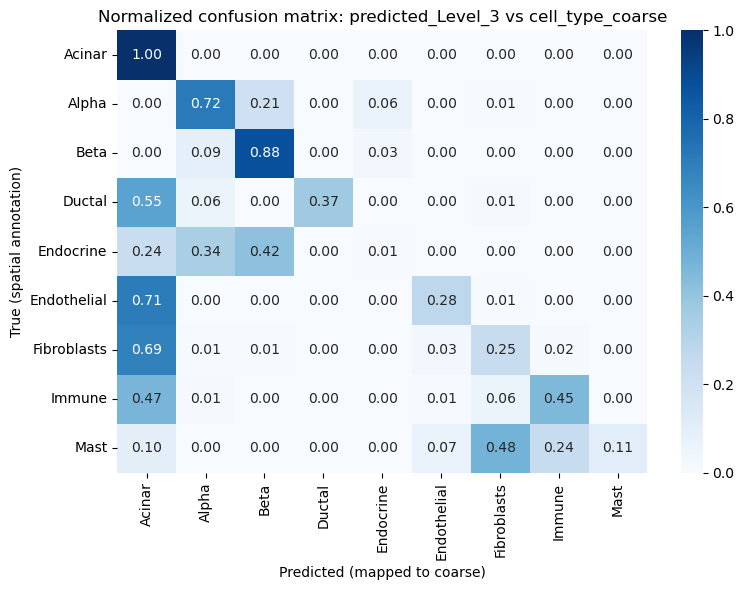

In [6]:
from sklearn.metrics import classification_report

LABEL_KEY = "cell_type_coarse"
PRED_KEY = "predicted_Level_3"

# Map fine Level_3 predictions to coarse spatial annotation labels
PRED_TO_COARSE = {
    "Acinar Cell": "Acinar",
    "Alpha Cell": "Alpha",
    "Beta Cell": "Beta",
    "Delta Cell": "Endocrine",
    "Ductal Cell": "Ductal",
    "Endothelial Cell": "Endothelial",
    "Fibroblast": "Fibroblasts",
    "Stellate Cell": "Fibroblasts",
    "Pericyte": "Fibroblasts",
    "Smooth Muscle Cell": "Fibroblasts",
    "Schwann Cell": "Fibroblasts",
    "Adipocyte": "Fibroblasts",
    "Macrophage": "Immune",
    "T Cell": "Immune",
    "NK Cell": "Immune",
    "Plasma Cell": "Immune",
    "Mast Cell": "Mast",
    "Mixed Endocrine Cell": "Endocrine",
    "Pancreatic Polypeptide Cell": "Endocrine",
    "Epsilon Cell": "Endocrine",
}

true_labels = adata[adata.obs.confidence_Level_3 > 0.7].obs[LABEL_KEY].astype(str)
pred_coarse = adata[adata.obs.confidence_Level_3 > 0.7].obs[PRED_KEY].astype(str).map(PRED_TO_COARSE)

unmapped = sorted(adata[adata.obs.confidence_Level_3 > 0.7].obs[PRED_KEY].astype(str)[pred_coarse.isna()].unique())
if unmapped:
    print(f"Warning: unmapped predictions: {unmapped}")

mask = true_labels.notna() & pred_coarse.notna()
accuracy = (true_labels[mask] == pred_coarse[mask]).mean()
n_correct = int((true_labels[mask] == pred_coarse[mask]).sum())
n_total = int(mask.sum())
n_wrong = n_total - n_correct

print(f"Label transfer accuracy ({PRED_KEY} -> {LABEL_KEY}): {accuracy:.1%}")
print(f"  {n_correct:,} / {n_total:,} cells correct ({n_wrong:,} misclassified)")

confusion = pd.crosstab(
    true_labels[mask], pred_coarse[mask], rownames=["true"], colnames=["predicted"]
)
display(confusion)

print(classification_report(true_labels[mask], pred_coarse[mask], zero_division=0))

# Normalized confusion matrix (fraction of each true label)
confusion_norm = confusion.div(confusion.sum(axis=1), axis=0)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title(f"Normalized confusion matrix: {PRED_KEY} vs {LABEL_KEY}")
plt.ylabel("True (spatial annotation)")
plt.xlabel("Predicted (mapped to coarse)")
plt.tight_layout()
plt.savefig('/lustre/groups/ml01/workspace/hpca/hpca_downstream/label_transfer_spatial/confusion_matrix_healthy.svg')
plt.show()

Label transfer accuracy (predicted_Level_3 -> cell_type_coarse): 74.3%
  80,723 / 108,711 cells correct (27,988 misclassified)


predicted,Acinar,Alpha,Beta,Ductal,Endocrine,Endothelial,Fibroblasts,Immune,Mast
true,,,,,,,,,
Acinar,62862,170,73,623,154,72,239,145,2
Alpha,0,1920,731,0,390,25,45,0,0
Beta,3,597,3232,0,368,2,0,0,0
Ductal,10353,1644,119,8114,506,51,456,104,5
Endocrine,386,346,318,4,6,1,1,1,0
Endothelial,1764,16,8,2,6,714,86,10,0
Fibroblasts,5196,171,94,17,49,282,2773,306,13
Immune,1111,69,11,42,23,55,284,994,3
Mast,66,11,7,4,8,44,193,103,108


              precision    recall  f1-score   support

      Acinar       0.77      0.98      0.86     64340
       Alpha       0.39      0.62      0.48      3111
        Beta       0.70      0.77      0.73      4202
      Ductal       0.92      0.38      0.54     21352
   Endocrine       0.00      0.01      0.00      1063
 Endothelial       0.57      0.27      0.37      2606
 Fibroblasts       0.68      0.31      0.43      8901
      Immune       0.60      0.38      0.47      2592
        Mast       0.82      0.20      0.32       544

    accuracy                           0.74    108711
   macro avg       0.61      0.44      0.47    108711
weighted avg       0.76      0.74      0.71    108711



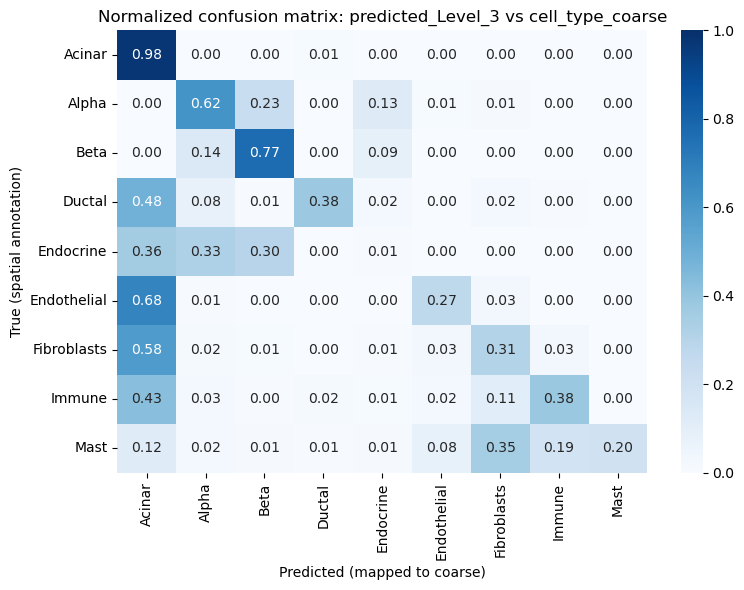

In [ ]:
from sklearn.metrics import classification_report

LABEL_KEY = "cell_type_coarse"
PRED_KEY = "predicted_Level_3"

# Map fine Level_3 predictions to coarse spatial annotation labels
PRED_TO_COARSE = {
    "Acinar Cell": "Acinar",
    "Alpha Cell": "Alpha",
    "Beta Cell": "Beta",
    "Delta Cell": "Endocrine",
    "Ductal Cell": "Ductal",
    "Endothelial Cell": "Endothelial",
    "Fibroblast": "Fibroblasts",
    "Stellate Cell": "Fibroblasts",
    "Pericyte": "Fibroblasts",
    "Smooth Muscle Cell": "Fibroblasts",
    "Schwann Cell": "Fibroblasts",
    "Adipocyte": "Fibroblasts",
    "Macrophage": "Immune",
    "T Cell": "Immune",
    "NK Cell": "Immune",
    "Plasma Cell": "Immune",
    "Mast Cell": "Mast",
    "Mixed Endocrine Cell": "Endocrine",
    "Pancreatic Polypeptide Cell": "Endocrine",
    "Epsilon Cell": "Endocrine",
}

true_labels = adata.obs[LABEL_KEY].astype(str)
pred_coarse = adata.obs[PRED_KEY].astype(str).map(PRED_TO_COARSE)

unmapped = sorted(adata.obs[PRED_KEY].astype(str)[pred_coarse.isna()].unique())
if unmapped:
    print(f"Warning: unmapped predictions: {unmapped}")

mask = true_labels.notna() & pred_coarse.notna()
accuracy = (true_labels[mask] == pred_coarse[mask]).mean()
n_correct = int((true_labels[mask] == pred_coarse[mask]).sum())
n_total = int(mask.sum())
n_wrong = n_total - n_correct

print(f"Label transfer accuracy ({PRED_KEY} -> {LABEL_KEY}): {accuracy:.1%}")
print(f"  {n_correct:,} / {n_total:,} cells correct ({n_wrong:,} misclassified)")

confusion = pd.crosstab(
    true_labels[mask], pred_coarse[mask], rownames=["true"], colnames=["predicted"]
)
display(confusion)

print(classification_report(true_labels[mask], pred_coarse[mask], zero_division=0))

# Normalized confusion matrix (fraction of each true label)
confusion_norm = confusion.div(confusion.sum(axis=1), axis=0)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title(f"Normalized confusion matrix: {PRED_KEY} vs {LABEL_KEY}")
plt.ylabel("True (spatial annotation)")
plt.xlabel("Predicted (mapped to coarse)")
plt.tight_layout()
plt.show()

In [19]:
import os

def label_transfer_accuracy(obs, label_key=LABEL_KEY, pred_key=PRED_KEY, pred_to_coarse=PRED_TO_COARSE):
    true = obs[label_key].astype(str)
    pred = obs[pred_key].astype(str).map(pred_to_coarse)
    mask = true.notna() & pred.notna()
    if mask.sum() == 0:
        return None
    correct = (true[mask] == pred[mask]).sum()
    total = mask.sum()
    return {
        "n_cells": int(total),
        "accuracy": correct / total,
        "n_correct": int(correct),
        "n_wrong": int(total - correct),
    }

rows = []
for path in sorted(adata_paths):
    sample = os.path.basename(path).replace("_annotated_l0.h5ad", "")
    adata_sample = sc.read_h5ad(path)
    stats = label_transfer_accuracy(adata_sample.obs)
    if stats is None:
        continue
    rows.append({"sample": sample, **stats})

accuracy_df = pd.DataFrame(rows)
display(accuracy_df.assign(accuracy=lambda df: df["accuracy"].map("{:.1%}".format)))

if len(accuracy_df) > 1:
    total_correct = accuracy_df["n_correct"].sum()
    total_cells = accuracy_df["n_cells"].sum()
    print(
        f"\nOverall accuracy across {len(accuracy_df)} samples: "
        f"{total_correct / total_cells:.1%} ({total_correct:,} / {total_cells:,} cells)"
    )

,sample,n_cells,accuracy,n_correct,n_wrong
0,S1,108711,74.3%,80723,27988
1,S2,126421,77.0%,97289,29132
2,S3,151595,51.2%,77576,74019



Overall accuracy across 3 samples: 66.1% (255,588 / 386,727 cells)


In [17]:
adata.obs.predicted_Level_3.unique()

['Acinar Cell', 'Ductal Cell', 'Beta Cell', 'Stellate Cell', 'Alpha Cell', ..., 'Plasma Cell', 'Adipocyte', 'Mast Cell', 'Schwann Cell', 'Epsilon Cell']
Length: 20
Categories (20, object): ['Acinar Cell', 'Adipocyte', 'Alpha Cell', 'Beta Cell', ..., 'Schwann Cell', 'Smooth Muscle Cell', 'Stellate Cell', 'T Cell']

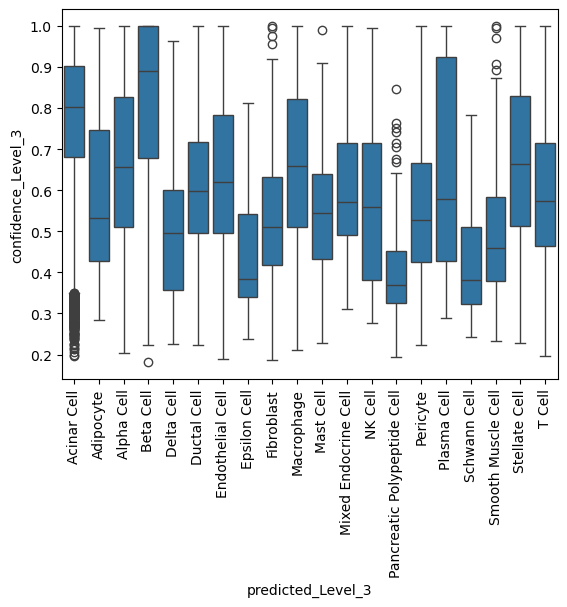

In [16]:
sns.boxplot(data=adata.obs, x='predicted_Level_3', y='confidence_Level_3', )
plt.xticks(rotation=90)
plt.show()


In [10]:
adata[adata.obs.predicted_Level_4 == 'Alpha-Beta-Delta Cell']

View of AnnData object with n_obs × n_vars = 898 × 957
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'predicted_Level_3', 'confidence_Level_3', 'predicted_Level_4', 'confidence_Level_4'
    var: 'NegPrb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'spatial'
    obsm: 'spatial', 'spatial_fov', 'tacco_scores_Level_3', 'tacco_scores_Level_4'
    layers: '

In [26]:
adata_high_conf = adata[adata.obs.confidence_Level_4 > 0.7]

In [25]:
adata[(adata.obs.predicted_Level_4 == 'Alpha-Beta-Delta Cell') & (adata.obs.confidence_Level_4 > 0.7)]

View of AnnData object with n_obs × n_vars = 90 × 957
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'predicted_Level_3', 'confidence_Level_3', 'predicted_Level_4', 'confidence_Level_4'
    var: 'NegPrb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'spatial'
    obsm: 'spatial', 'spatial_fov', 'tacco_scores_Level_3', 'tacco_scores_Level_4'
    layers: 'c

In [30]:
adata[(adata.obs.predicted_Level_3 == 'Mixed Endocrine Cell') & (adata.obs.confidence_Level_3 > 0.7)]

View of AnnData object with n_obs × n_vars = 168 × 957
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'predicted_Level_3', 'confidence_Level_3', 'predicted_Level_4', 'confidence_Level_4'
    var: 'NegPrb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'spatial'
    obsm: 'spatial', 'spatial_fov', 'tacco_scores_Level_3', 'tacco_scores_Level_4'
    layers: '

In [ ]:
# Goal: Check if 'Alpha-Beta-Delta Cell' (Level_4 label in dissociated atlas) is present in the spatial data (adata).
# Approach: Find marker genes upregulated in Alpha-Beta-Delta Cells in the dissociated data, calculate expression scores in adata.

# 1. Identify marker genes for 'Alpha-Beta-Delta Cell' in atlas
sc.tl.rank_genes_groups(
    adata_dissoc, 
    groupby='Level_4', 
    method='wilcoxon', 
    groups=['Alpha-Beta-Delta Cell']
)
# Get top 20 marker genes
top_abd_genes = (
    pd.DataFrame(adata_dissoc.uns['rank_genes_groups']['names'])
    .loc[:19, 'Alpha-Beta-Delta Cell']
    .values.tolist()
)

# 2. Score spatial cells for the 'Alpha-Beta-Delta Cell' signature
sc.tl.score_genes(adata, top_abd_genes, score_name='alpha_beta_delta_cell_score')

# 3. Visualize the score distribution and spatial mapping
plt.figure()
sns.histplot(adata.obs['alpha_beta_delta_cell_score'], bins=50, kde=True)
plt.title('Alpha-Beta-Delta Cell Score Distribution in Spatial Data')
plt.xlabel('Score')
plt.ylabel('Cell count')
plt.show()

sc.pl.umap(adata, color="alpha_beta_delta_cell_score", cmap="viridis")

# Optionally: Show highly scoring cells in a table
high_score_cells = adata.obs[adata.obs['alpha_beta_delta_cell_score'] > adata.obs['alpha_beta_delta_cell_score'].quantile(0.99)]
display(high_score_cells[['alpha_beta_delta_cell_score', 'predicted_Level_3_filtered', 'cell_type_coarse']])

In [25]:
cross_tab = pd.crosstab(adata.obs.cell_type_coarse, adata.obs.predicted_Level_4).T
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None):
    display(cross_tab)

cell_type_coarse,Acinar,Alpha,Beta,Ductal,Endocrine,Endothelial,Fibroblasts,Immune,Mast
predicted_Level_4,,,,,,,,,
Acinar Cell,393,0,0,273,6,22,67,15,1
Acinar Cell: ADM Plasticity,861,0,0,1133,4,2,3,2,0
Acinar Cell: CBS,64,0,0,49,0,7,22,14,4
Acinar Cell: Digestive Secretion,3249,0,0,440,29,73,316,68,2
Acinar Cell: Idling,14626,0,3,1129,74,287,423,184,17
Acinar Cell: Injury Response,2213,0,0,192,12,36,143,37,1
Acinar Cell: Interferon Response,3806,0,0,453,8,29,42,23,1
Acinar Cell: Oxidative Stress,690,0,0,77,0,15,10,4,0
Acinar Cell: PanIN,18,0,0,18,0,0,6,2,2


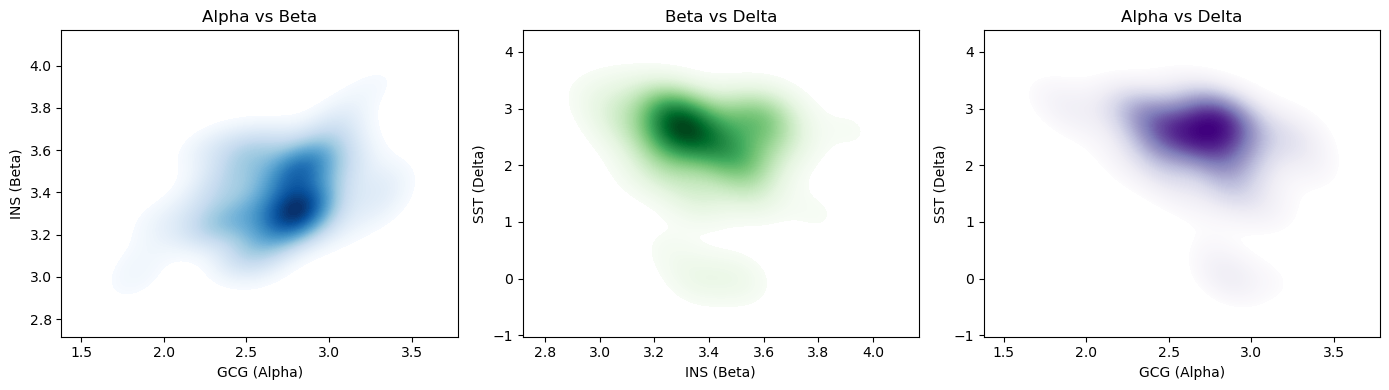

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define canonical marker genes for Alpha, Beta, and Delta cells
alpha_marker = "GCG"   # Glucagon, Alpha-cell marker
beta_marker = "INS"    # Insulin, Beta-cell marker
delta_marker = "SST"   # Somatostatin, Delta-cell marker

# Subset the AnnData object to predicted Alpha-Beta-Delta Cells
abd_cells = adata[adata.obs['predicted_Level_4'] == 'Alpha-Beta-Delta Cell']
abd_cells = abd_cells[abd_cells.obs['confidence_Level_4'] > 0.7]

# Check if marker genes are present in var_names (if not, try to use .gene_name or .gene_names)
def get_gene_index(adata, gene):
    if gene in adata.var_names:
        return gene
    # Try column gene_name if present
    elif 'gene_name' in adata.var.columns and gene in adata.var['gene_name'].values:
        return adata.var.index[adata.var['gene_name'] == gene][0]
    elif 'gene_names' in adata.var.columns and gene in adata.var['gene_names'].values:
        return adata.var.index[adata.var['gene_names'] == gene][0]
    else:
        raise ValueError(f"Could not find gene {gene} in var_names or gene_name columns of adata.var.")

alpha_idx = get_gene_index(abd_cells, alpha_marker)
beta_idx = get_gene_index(abd_cells, beta_marker)
delta_idx = get_gene_index(abd_cells, delta_marker)

# Extract expression values
alpha_expr = abd_cells[:, alpha_idx].X.toarray().flatten() if hasattr(abd_cells[:, alpha_idx].X, "toarray") else abd_cells[:, alpha_idx].X.flatten()
beta_expr = abd_cells[:, beta_idx].X.toarray().flatten() if hasattr(abd_cells[:, beta_idx].X, "toarray") else abd_cells[:, beta_idx].X.flatten()
delta_expr = abd_cells[:, delta_idx].X.toarray().flatten() if hasattr(abd_cells[:, delta_idx].X, "toarray") else abd_cells[:, delta_idx].X.flatten()

# Plot density plots (2D kernel density estimate) instead of scatter plots
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.kdeplot(
    x=alpha_expr,
    y=beta_expr,
    fill=True,
    cmap="Blues",
    thresh=0.05,
    levels=100
)
plt.xlabel(f'{alpha_marker} (Alpha)')
plt.ylabel(f'{beta_marker} (Beta)')
plt.title('Alpha vs Beta')

plt.subplot(1, 3, 2)
sns.kdeplot(
    x=beta_expr,
    y=delta_expr,
    fill=True,
    cmap="Greens",
    thresh=0.05,
    levels=100
)
plt.xlabel(f'{beta_marker} (Beta)')
plt.ylabel(f'{delta_marker} (Delta)')
plt.title('Beta vs Delta')

plt.subplot(1, 3, 3)
sns.kdeplot(
    x=alpha_expr,
    y=delta_expr,
    fill=True,
    cmap="Purples",
    thresh=0.05,
    levels=100
)
plt.xlabel(f'{alpha_marker} (Alpha)')
plt.ylabel(f'{delta_marker} (Delta)')
plt.title('Alpha vs Delta')

plt.tight_layout()
plt.savefig('/lustre/groups/ml01/workspace/hpca/hpca_downstream/label_transfer_spatial/Alpha_Beta_Delta_marker_expression.svg', format='svg', bbox_inches='tight', pad_inches=0.3)
plt.show()

In [15]:
pancreas_markers = {
    "alpha": [
        "ARX", 
        "IRX2", 
        "TM4SF4", 
        "DPP4", 
        "LOXL4"
    ],
    "beta": [
        "PDX1", 
        "NKX6-1", 
        "MAFA", 
        "SLC30A8", 
        "ABCC8", 
        "KCNJ11", 
        "IAPP", 
        "CHGB"
    ],
    "delta": [
        "HHEX", 
        "LEPR", 
        "GHSR", 
        "RBP4", 
        "BHLHE41"
    ]
}

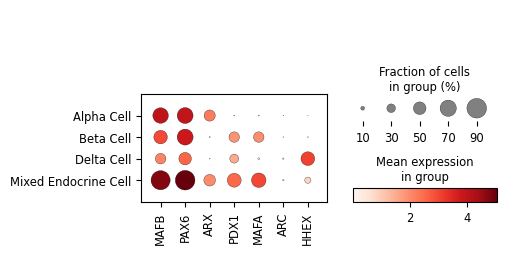

In [10]:
sc.pl.dotplot(adata_dissoc[adata_dissoc.obs.Level_3.isin(['Alpha Cell', 'Beta Cell', 'Delta Cell', 'Mixed Endocrine Cell'])], var_names=['MAFB', 'PAX6', 'ARX', 'PDX1', 'MAFA', 'ARC', 'HHEX'], groupby='Level_3', )

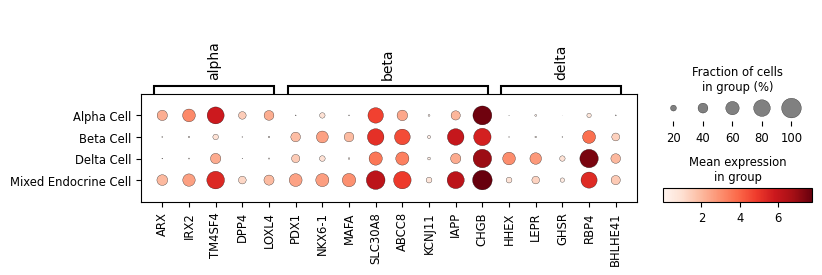

In [16]:
sc.pl.dotplot(adata_dissoc[adata_dissoc.obs.Level_3.isin(['Alpha Cell', 'Beta Cell', 'Delta Cell', 'Mixed Endocrine Cell'])], var_names=pancreas_markers, groupby='Level_3', )

In [20]:
adata_dissoc_abd = adata_dissoc[adata_dissoc.obs.Level_3.isin(['Alpha Cell', 'Beta Cell', 'Delta Cell'])]

In [21]:
sc.tl.rank_genes_groups(adata_dissoc_abd, groupby='Level_3')

/home/icb/daniel.strobl/miniconda3/envs/scanpy_26/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:679: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


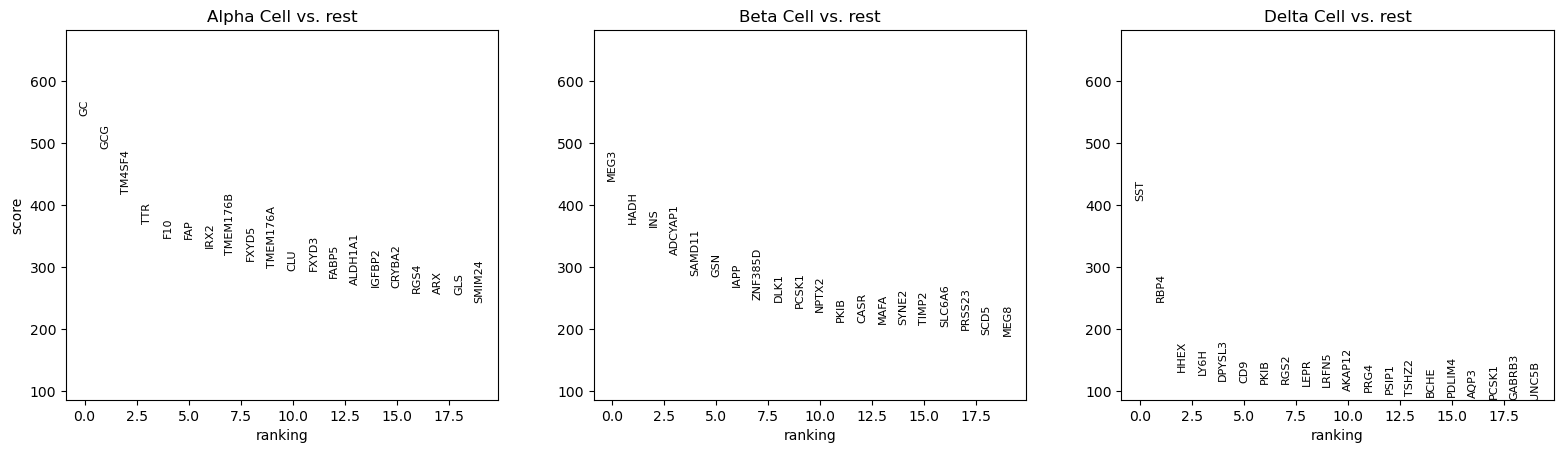

In [23]:
sc.pl.rank_genes_groups(adata_dissoc_abd, )

In [43]:
markers_dict = {
    'alpha': list(set(sc.get.rank_genes_groups_df(adata_dissoc_abd, group='Alpha Cell')[:50].names.tolist()).intersection(adata.var_names)),
    'beta': list(set(sc.get.rank_genes_groups_df(adata_dissoc_abd, group='Beta Cell')[:50].names.tolist()).intersection(adata.var_names)),
    'delta': list(set(sc.get.rank_genes_groups_df(adata_dissoc_abd, group='Delta Cell')[:50].names.tolist()).intersection(adata.var_names))
    }

In [44]:
markers_dict

{'alpha': ['CD36',
  'CLU',
  'GPX3',
  'B2M',
  'HLA-A',
  'SERPINA1',
  'GCG',
  'FABP5',
  'VIM',
  'DPP4',
  'TTR',
  'GC',
  'HLA-E',
  'HLA-B'],
 'beta': ['INS', 'MEG3', 'GSN', 'G6PC2', 'NRG1', 'IAPP', 'CASR', 'BMP5'],
 'delta': ['CD9',
  'AQP3',
  'SST',
  'TSHZ2',
  'ADGRL2',
  'RGS2',
  'FFAR4',
  'CASR',
  'CALB1',
  'DHRS2']}

/tmp/ipykernel_1231569/2297735101.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(adata_dissoc[adata_dissoc.obs.Level_3.isin(['Alpha Cell', 'Beta Cell', 'Delta Cell', 'Mixed Endocrine Cell'])], var_names=markers_dict, groupby='Level_3', save='markers_dissoc.svg')


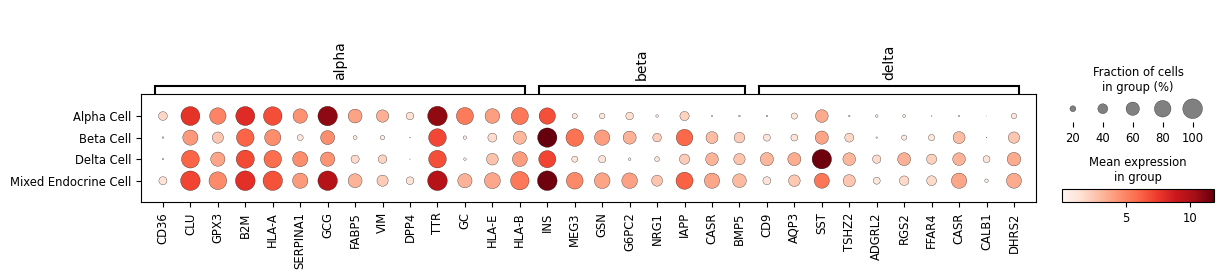

In [53]:
sc.pl.dotplot(adata_dissoc[adata_dissoc.obs.Level_3.isin(['Alpha Cell', 'Beta Cell', 'Delta Cell', 'Mixed Endocrine Cell'])], var_names=markers_dict, groupby='Level_3', save='markers_dissoc.svg')

In [47]:
adata

AnnData object with n_obs × n_vars = 108711 × 957
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'predicted_Level_3', 'confidence_Level_3', 'predicted_Level_4', 'confidence_Level_4'
    var: 'NegPrb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'spatial'
    obsm: 'spatial', 'spatial_fov', 'tacco_scores_Level_3', 'tacco_scores_Level_4'
    layers: 'count

/tmp/ipykernel_1231569/2967367786.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(adata[(adata.obs.predicted_Level_3.isin(['Alpha Cell', 'Beta Cell', 'Delta Cell', 'Mixed Endocrine Cell']))& (adata.obs.confidence_Level_3 > 0.7)], var_names=markers_dict, groupby='predicted_Level_3', save='markers_spatial.svg')


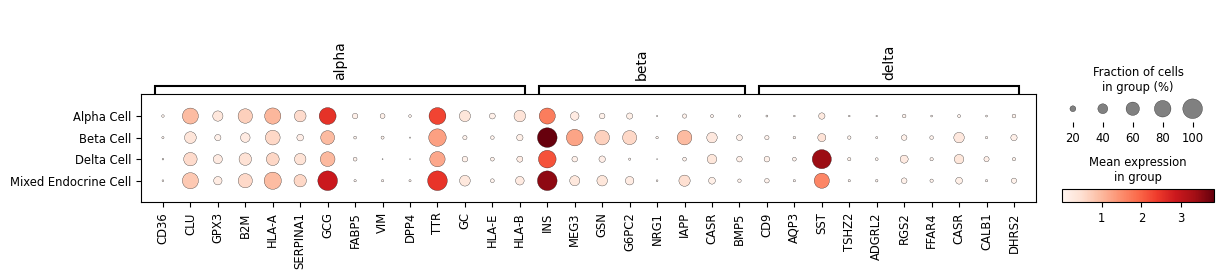

In [54]:
sc.pl.dotplot(adata[(adata.obs.predicted_Level_3.isin(['Alpha Cell', 'Beta Cell', 'Delta Cell', 'Mixed Endocrine Cell']))& (adata.obs.confidence_Level_3 > 0.7)], var_names=markers_dict, groupby='predicted_Level_3', save='markers_spatial.svg')

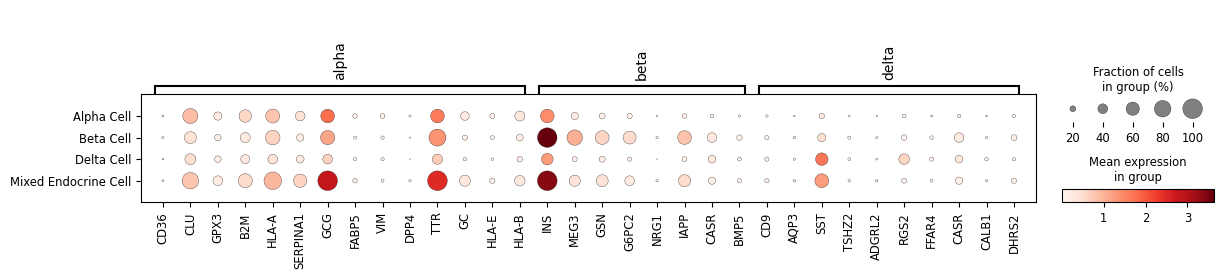

In [49]:
sc.pl.dotplot(adata[(adata.obs.predicted_Level_3.isin(['Alpha Cell', 'Beta Cell', 'Delta Cell', 'Mixed Endocrine Cell']))], var_names=markers_dict, groupby='predicted_Level_3', )

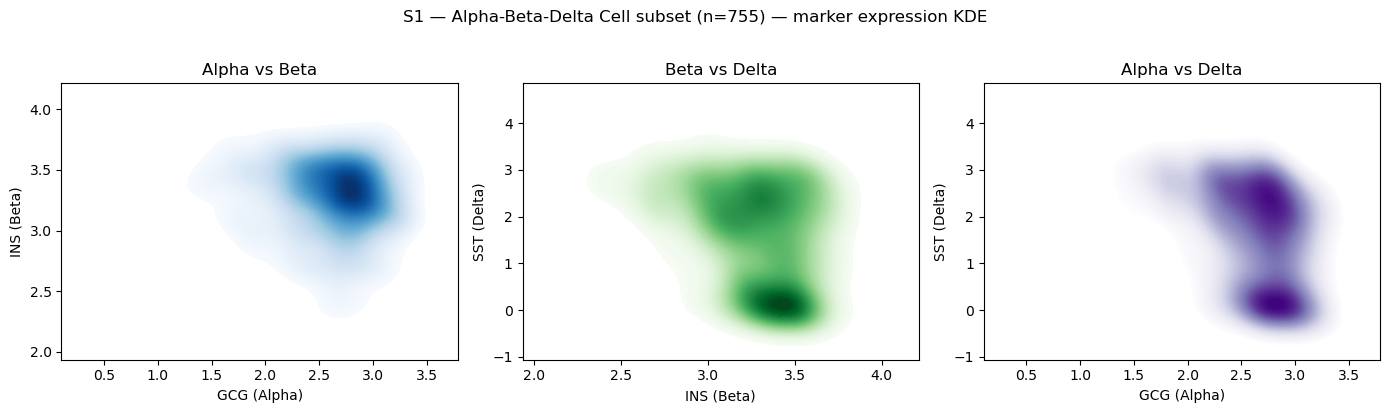

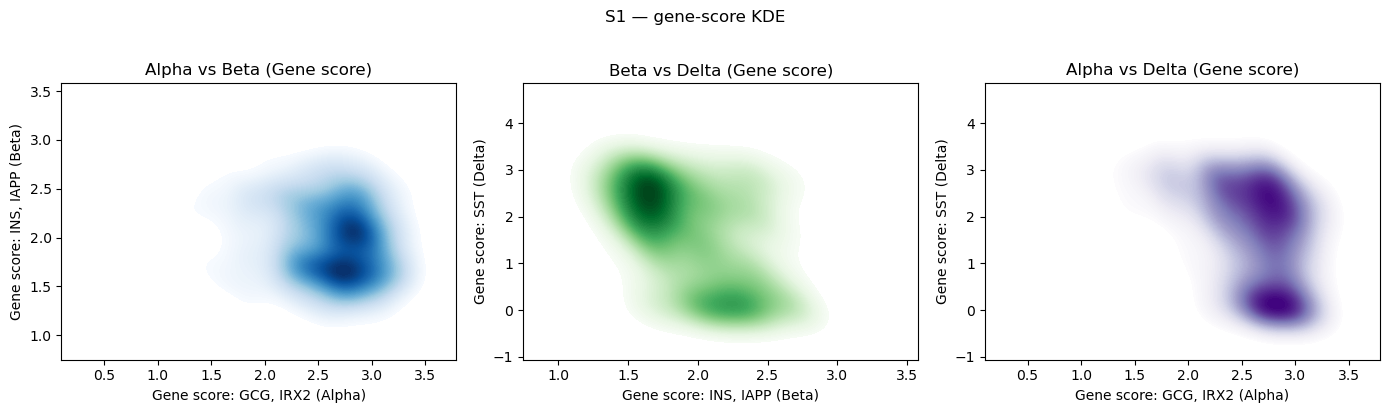

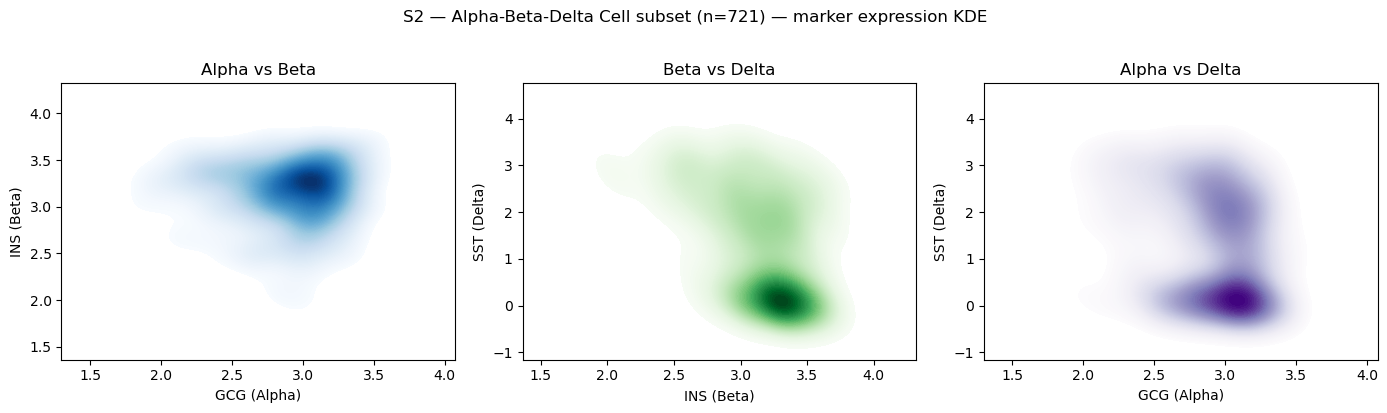

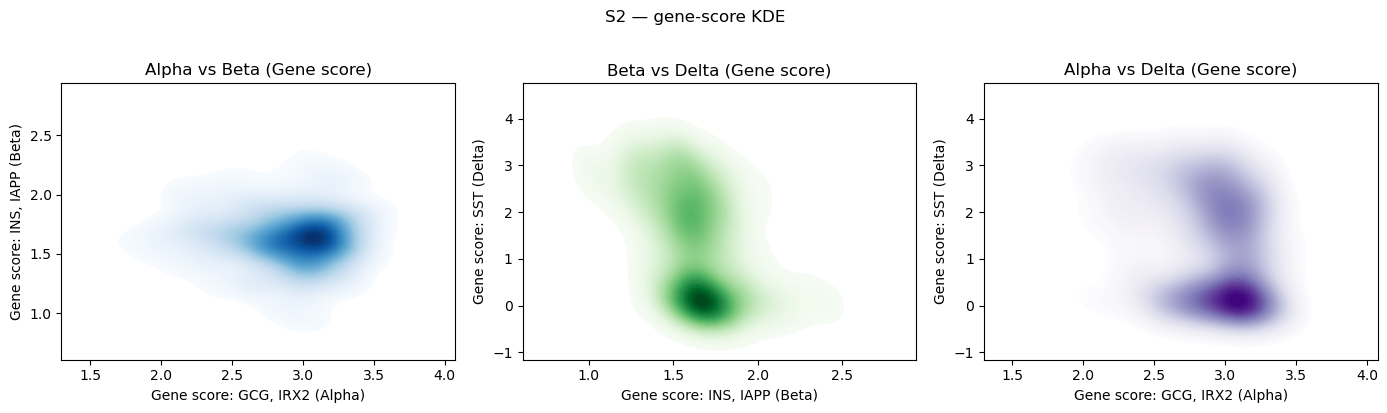

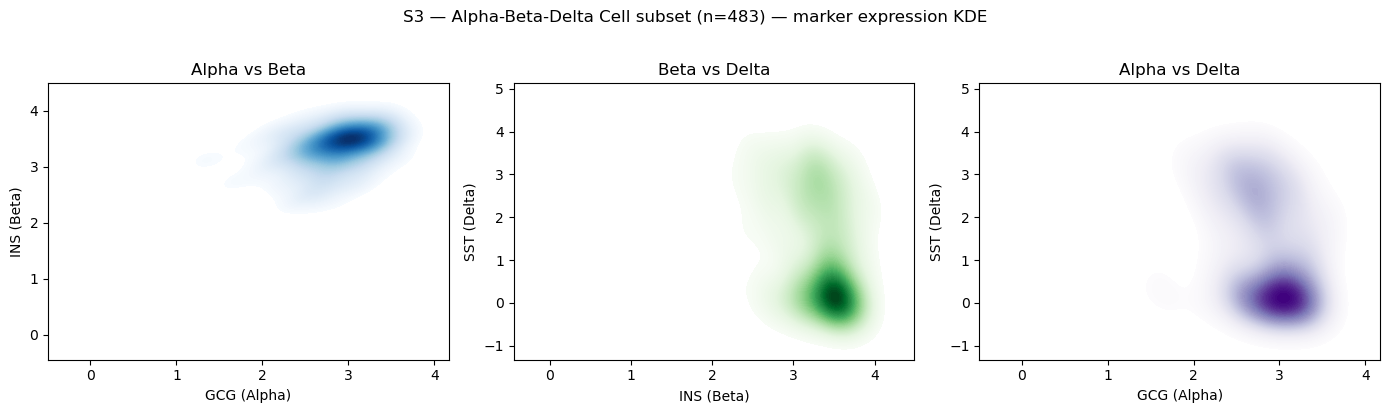

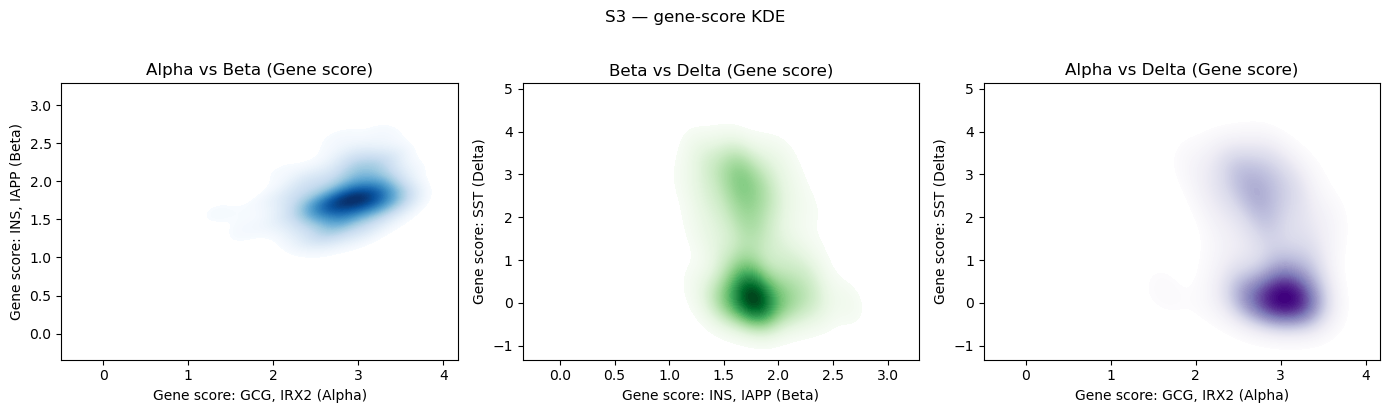

In [7]:
# Batch density plots (2D KDE): same marker and gene-score panels as above, for every spatial h5ad in adata_paths
import os

alpha_marker = "GCG"
beta_marker = "INS"
delta_marker = "SST"
alpha_markers = ["GCG", "IRX2"]
beta_markers = [ "IAPP", "PDX1", "MAFA"]
delta_markers = ["SST"]


def get_gene_index(adata, gene):
    if gene in adata.var_names:
        return gene
    elif "gene_name" in adata.var.columns and gene in adata.var["gene_name"].values:
        return adata.var.index[adata.var["gene_name"] == gene][0]
    elif "gene_names" in adata.var.columns and gene in adata.var["gene_names"].values:
        return adata.var.index[adata.var["gene_names"] == gene][0]
    else:
        raise ValueError(f"Could not find gene {gene} in var_names or gene_name columns of adata.var.")


def compute_gene_score(adata, marker_genes):
    gene_indices = [adata.var_names.get_loc(g) for g in marker_genes if g in adata.var_names]
    if len(gene_indices) == 0:
        raise ValueError(f"No marker genes found in adata: {marker_genes}")
    X_selected = adata[:, gene_indices].X
    if hasattr(X_selected, "toarray"):
        X_selected = X_selected.toarray()
    return X_selected.mean(axis=1)


for path in sorted(adata_paths):
    sample = os.path.basename(path).replace("_annotated_l0.h5ad", "")
    adata_batch = sc.read_h5ad(path)
    if "predicted_Level_4" not in adata_batch.obs.columns:
        print(f"[skip] {sample}: no column predicted_Level_4")
        continue
    abd_b = adata_batch[adata_batch.obs["predicted_Level_4"] == "Alpha-Beta-Delta Cell"]
    if abd_b.n_obs == 0:
        print(f"[skip] {sample}: no cells with predicted_Level_4 == 'Alpha-Beta-Delta Cell'")
        continue
    try:
        a_idx = get_gene_index(abd_b, alpha_marker)
        b_idx = get_gene_index(abd_b, beta_marker)
        d_idx = get_gene_index(abd_b, delta_marker)
        alpha_expr = (
            abd_b[:, a_idx].X.toarray().flatten()
            if hasattr(abd_b[:, a_idx].X, "toarray")
            else abd_b[:, a_idx].X.flatten()
        )
        beta_expr = (
            abd_b[:, b_idx].X.toarray().flatten()
            if hasattr(abd_b[:, b_idx].X, "toarray")
            else abd_b[:, b_idx].X.flatten()
        )
        delta_expr = (
            abd_b[:, d_idx].X.toarray().flatten()
            if hasattr(abd_b[:, d_idx].X, "toarray")
            else abd_b[:, d_idx].X.flatten()
        )
    except Exception as e:
        print(f"[skip] {sample} (marker lookup): {e}")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"{sample} — Alpha-Beta-Delta Cell subset (n={abd_b.n_obs}) — marker expression KDE", y=1.02)
    sns.kdeplot(x=alpha_expr, y=beta_expr, ax=axes[0], fill=True, cmap="Blues", thresh=0.05, levels=100)
    axes[0].set_xlabel(f"{alpha_marker} (Alpha)")
    axes[0].set_ylabel(f"{beta_marker} (Beta)")
    axes[0].set_title("Alpha vs Beta")
    sns.kdeplot(x=beta_expr, y=delta_expr, ax=axes[1], fill=True, cmap="Greens", thresh=0.05, levels=100)
    axes[1].set_xlabel(f"{beta_marker} (Beta)")
    axes[1].set_ylabel(f"{delta_marker} (Delta)")
    axes[1].set_title("Beta vs Delta")
    sns.kdeplot(x=alpha_expr, y=delta_expr, ax=axes[2], fill=True, cmap="Purples", thresh=0.05, levels=100)
    axes[2].set_xlabel(f"{alpha_marker} (Alpha)")
    axes[2].set_ylabel(f"{delta_marker} (Delta)")
    axes[2].set_title("Alpha vs Delta")
    plt.tight_layout()
    plt.show()

    try:
        alpha_score = compute_gene_score(abd_b, alpha_markers)
        beta_score = compute_gene_score(abd_b, beta_markers)
        delta_score = compute_gene_score(abd_b, delta_markers)
    except Exception as e:
        print(f"[skip] {sample} gene-score KDE: {e}")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"{sample} — gene-score KDE", y=1.02)
    sns.kdeplot(x=alpha_score, y=beta_score, ax=axes[0], fill=True, cmap="Blues", thresh=0.05, levels=100)
    axes[0].set_xlabel(f"Gene score: {', '.join(alpha_markers)} (Alpha)")
    axes[0].set_ylabel(f"Gene score: {', '.join(beta_markers)} (Beta)")
    axes[0].set_title("Alpha vs Beta (Gene score)")
    sns.kdeplot(x=beta_score, y=delta_score, ax=axes[1], fill=True, cmap="Greens", thresh=0.05, levels=100)
    axes[1].set_xlabel(f"Gene score: {', '.join(beta_markers)} (Beta)")
    axes[1].set_ylabel(f"Gene score: {', '.join(delta_markers)} (Delta)")
    axes[1].set_title("Beta vs Delta (Gene score)")
    sns.kdeplot(x=alpha_score, y=delta_score, ax=axes[2], fill=True, cmap="Purples", thresh=0.05, levels=100)
    axes[2].set_xlabel(f"Gene score: {', '.join(alpha_markers)} (Alpha)")
    axes[2].set_ylabel(f"Gene score: {', '.join(delta_markers)} (Delta)")
    axes[2].set_title("Alpha vs Delta (Gene score)")
    plt.tight_layout()
    plt.show()


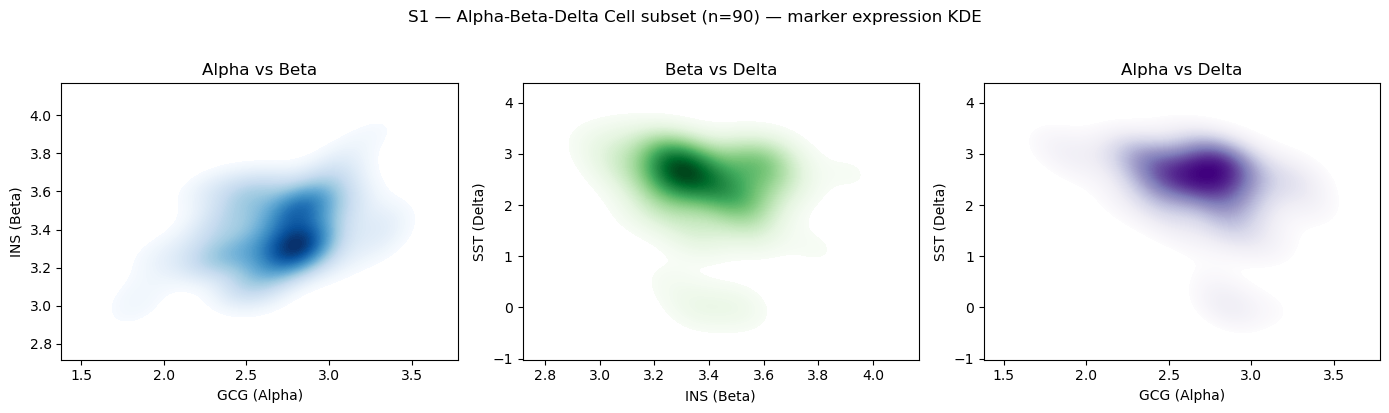

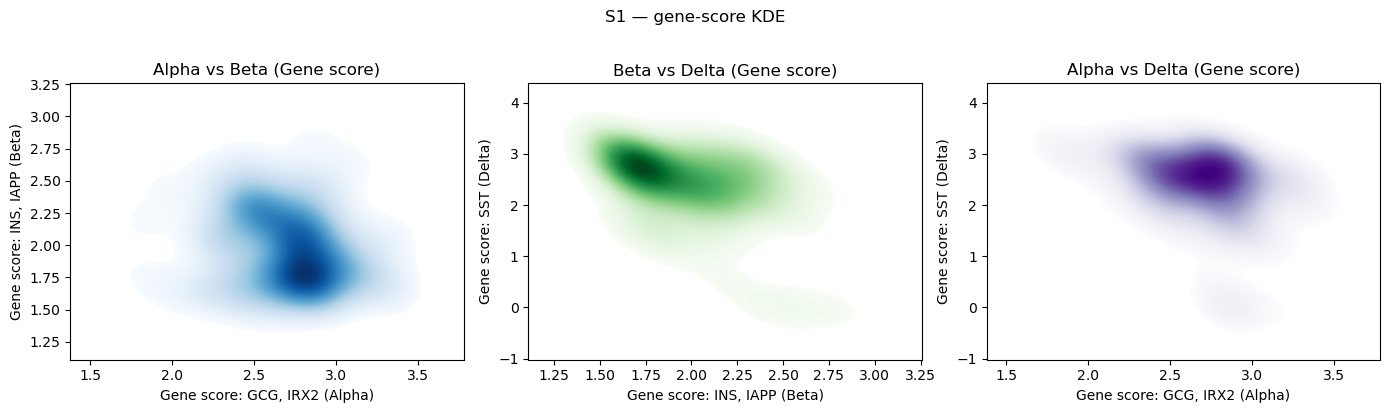

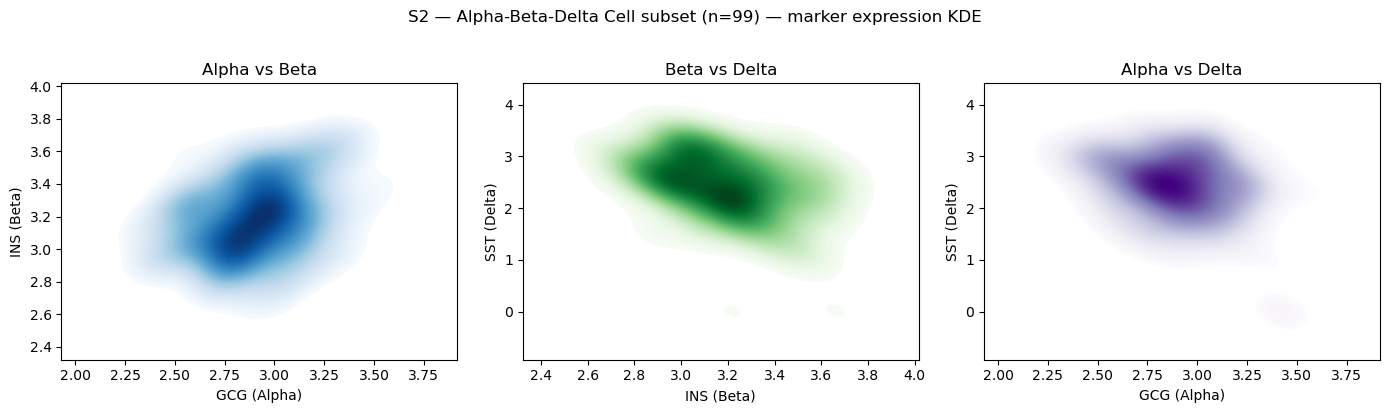

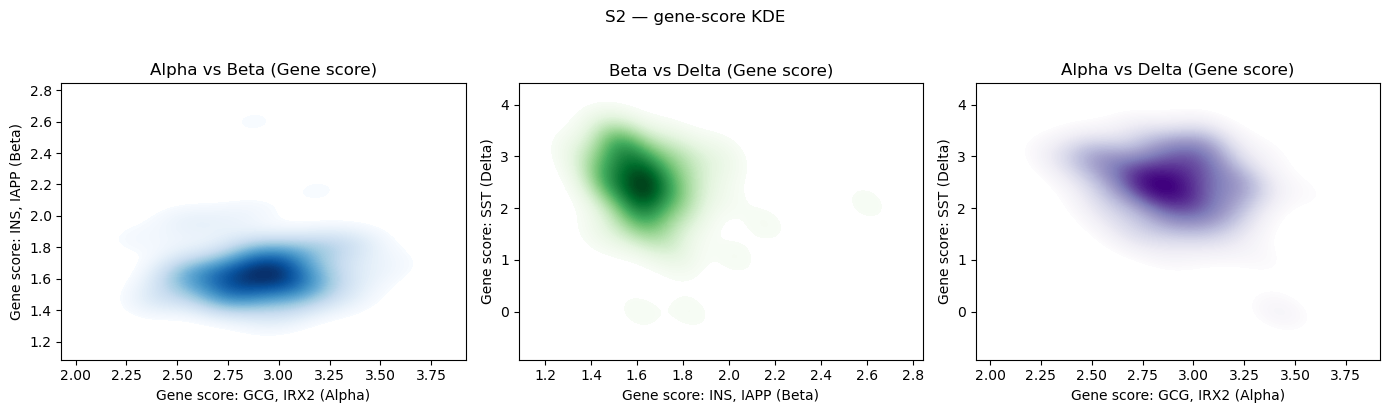

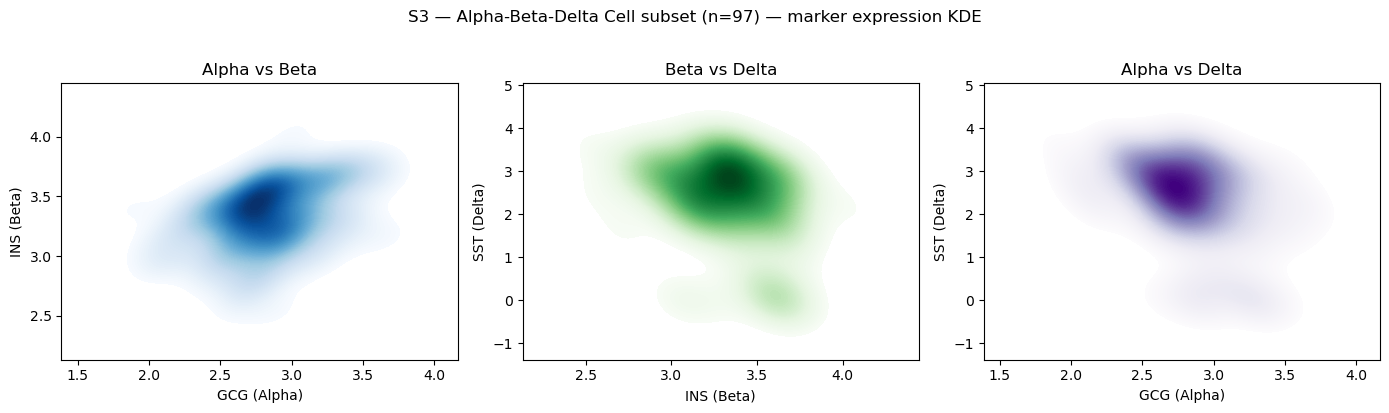

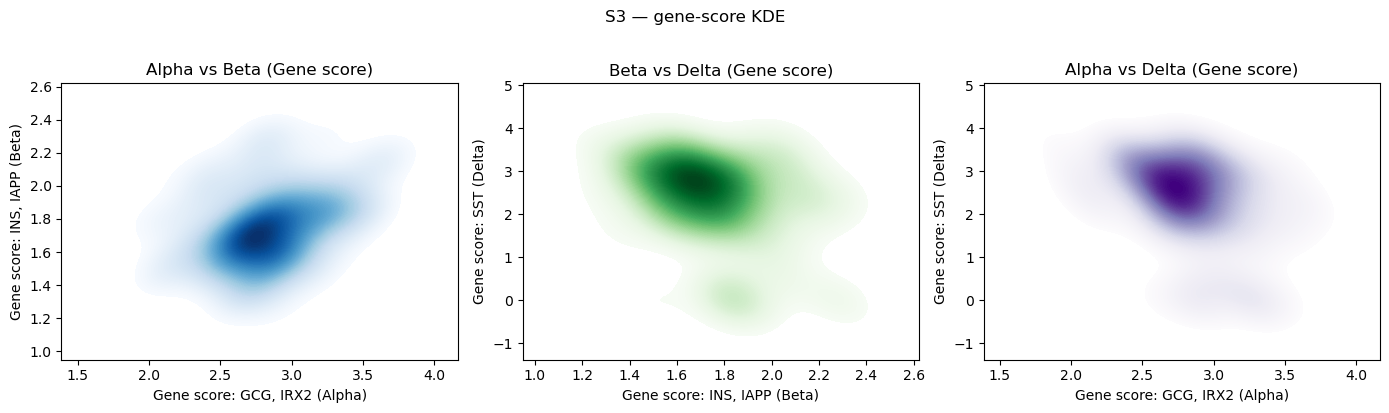

In [31]:
# Batch density plots (2D KDE): same marker and gene-score panels as above, for every spatial h5ad in adata_paths
import os

alpha_marker = "GCG"
beta_marker = "INS"
delta_marker = "SST"
alpha_markers = ["GCG", "IRX2"]
beta_markers = ["INS", "IAPP"]
delta_markers = ["SST"]


def get_gene_index(adata, gene):
    if gene in adata.var_names:
        return gene
    elif "gene_name" in adata.var.columns and gene in adata.var["gene_name"].values:
        return adata.var.index[adata.var["gene_name"] == gene][0]
    elif "gene_names" in adata.var.columns and gene in adata.var["gene_names"].values:
        return adata.var.index[adata.var["gene_names"] == gene][0]
    else:
        raise ValueError(f"Could not find gene {gene} in var_names or gene_name columns of adata.var.")


def compute_gene_score(adata, marker_genes):
    gene_indices = [adata.var_names.get_loc(g) for g in marker_genes if g in adata.var_names]
    if len(gene_indices) == 0:
        raise ValueError(f"No marker genes found in adata: {marker_genes}")
    X_selected = adata[:, gene_indices].X
    if hasattr(X_selected, "toarray"):
        X_selected = X_selected.toarray()
    return X_selected.mean(axis=1)


for path in sorted(adata_paths):
    sample = os.path.basename(path).replace("_annotated_l0.h5ad", "")
    adata_batch = sc.read_h5ad(path)
    adata_batch = adata_batch[adata_batch.obs.confidence_Level_4 > 0.7]
    if "predicted_Level_4" not in adata_batch.obs.columns:
        print(f"[skip] {sample}: no column predicted_Level_4")
        continue
    abd_b = adata_batch[adata_batch.obs["predicted_Level_4"] == "Alpha-Beta-Delta Cell"]
    if abd_b.n_obs == 0:
        print(f"[skip] {sample}: no cells with predicted_Level_4 == 'Alpha-Beta-Delta Cell'")
        continue
    try:
        a_idx = get_gene_index(abd_b, alpha_marker)
        b_idx = get_gene_index(abd_b, beta_marker)
        d_idx = get_gene_index(abd_b, delta_marker)
        alpha_expr = (
            abd_b[:, a_idx].X.toarray().flatten()
            if hasattr(abd_b[:, a_idx].X, "toarray")
            else abd_b[:, a_idx].X.flatten()
        )
        beta_expr = (
            abd_b[:, b_idx].X.toarray().flatten()
            if hasattr(abd_b[:, b_idx].X, "toarray")
            else abd_b[:, b_idx].X.flatten()
        )
        delta_expr = (
            abd_b[:, d_idx].X.toarray().flatten()
            if hasattr(abd_b[:, d_idx].X, "toarray")
            else abd_b[:, d_idx].X.flatten()
        )
    except Exception as e:
        print(f"[skip] {sample} (marker lookup): {e}")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"{sample} — Alpha-Beta-Delta Cell subset (n={abd_b.n_obs}) — marker expression KDE", y=1.02)
    sns.kdeplot(x=alpha_expr, y=beta_expr, ax=axes[0], fill=True, cmap="Blues", thresh=0.05, levels=100)
    axes[0].set_xlabel(f"{alpha_marker} (Alpha)")
    axes[0].set_ylabel(f"{beta_marker} (Beta)")
    axes[0].set_title("Alpha vs Beta")
    sns.kdeplot(x=beta_expr, y=delta_expr, ax=axes[1], fill=True, cmap="Greens", thresh=0.05, levels=100)
    axes[1].set_xlabel(f"{beta_marker} (Beta)")
    axes[1].set_ylabel(f"{delta_marker} (Delta)")
    axes[1].set_title("Beta vs Delta")
    sns.kdeplot(x=alpha_expr, y=delta_expr, ax=axes[2], fill=True, cmap="Purples", thresh=0.05, levels=100)
    axes[2].set_xlabel(f"{alpha_marker} (Alpha)")
    axes[2].set_ylabel(f"{delta_marker} (Delta)")
    axes[2].set_title("Alpha vs Delta")
    plt.tight_layout()
    plt.show()

    try:
        alpha_score = compute_gene_score(abd_b, alpha_markers)
        beta_score = compute_gene_score(abd_b, beta_markers)
        delta_score = compute_gene_score(abd_b, delta_markers)
    except Exception as e:
        print(f"[skip] {sample} gene-score KDE: {e}")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"{sample} — gene-score KDE", y=1.02)
    sns.kdeplot(x=alpha_score, y=beta_score, ax=axes[0], fill=True, cmap="Blues", thresh=0.05, levels=100)
    axes[0].set_xlabel(f"Gene score: {', '.join(alpha_markers)} (Alpha)")
    axes[0].set_ylabel(f"Gene score: {', '.join(beta_markers)} (Beta)")
    axes[0].set_title("Alpha vs Beta (Gene score)")
    sns.kdeplot(x=beta_score, y=delta_score, ax=axes[1], fill=True, cmap="Greens", thresh=0.05, levels=100)
    axes[1].set_xlabel(f"Gene score: {', '.join(beta_markers)} (Beta)")
    axes[1].set_ylabel(f"Gene score: {', '.join(delta_markers)} (Delta)")
    axes[1].set_title("Beta vs Delta (Gene score)")
    sns.kdeplot(x=alpha_score, y=delta_score, ax=axes[2], fill=True, cmap="Purples", thresh=0.05, levels=100)
    axes[2].set_xlabel(f"Gene score: {', '.join(alpha_markers)} (Alpha)")
    axes[2].set_ylabel(f"Gene score: {', '.join(delta_markers)} (Delta)")
    axes[2].set_title("Alpha vs Delta (Gene score)")
    plt.tight_layout()
    plt.show()


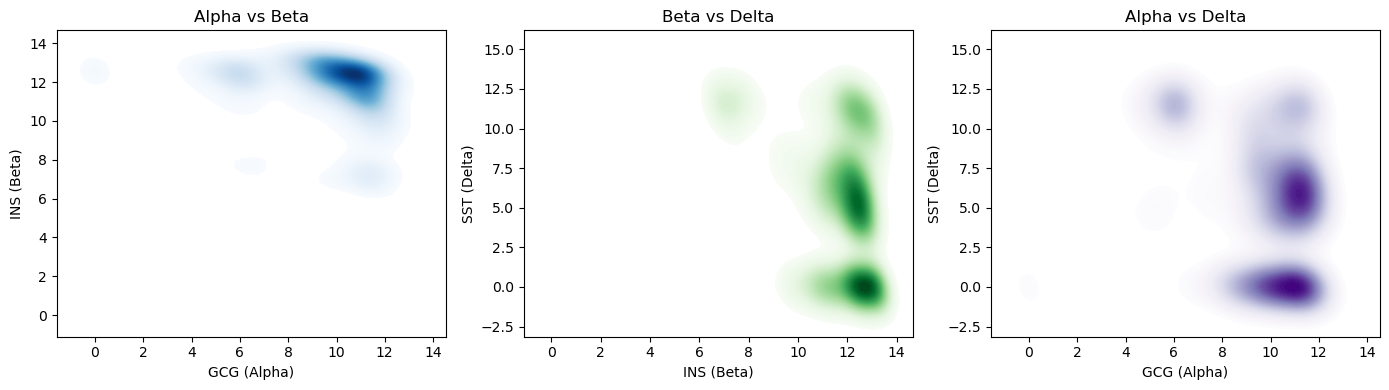

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define canonical marker genes for Alpha, Beta, and Delta cells
alpha_marker = "GCG"   # Glucagon, Alpha-cell marker
beta_marker = "INS"    # Insulin, Beta-cell marker
delta_marker = "SST"   # Somatostatin, Delta-cell marker

# Subset the AnnData object to predicted Alpha-Beta-Delta Cells
abd_cells = adata_dissoc[adata_dissoc.obs['Level_4'] == 'Alpha-Beta-Delta Cell']

# Check if marker genes are present in var_names (if not, try to use .gene_name or .gene_names)
def get_gene_index(adata, gene):
    if gene in adata.var_names:
        return gene
    # Try column gene_name if present
    elif 'gene_name' in adata.var.columns and gene in adata.var['gene_name'].values:
        return adata.var.index[adata.var['gene_name'] == gene][0]
    elif 'gene_names' in adata.var.columns and gene in adata.var['gene_names'].values:
        return adata.var.index[adata.var['gene_names'] == gene][0]
    else:
        raise ValueError(f"Could not find gene {gene} in var_names or gene_name columns of adata.var.")

alpha_idx = get_gene_index(abd_cells, alpha_marker)
beta_idx = get_gene_index(abd_cells, beta_marker)
delta_idx = get_gene_index(abd_cells, delta_marker)

# Extract expression values
alpha_expr = abd_cells[:, alpha_idx].X.toarray().flatten() if hasattr(abd_cells[:, alpha_idx].X, "toarray") else abd_cells[:, alpha_idx].X.flatten()
beta_expr = abd_cells[:, beta_idx].X.toarray().flatten() if hasattr(abd_cells[:, beta_idx].X, "toarray") else abd_cells[:, beta_idx].X.flatten()
delta_expr = abd_cells[:, delta_idx].X.toarray().flatten() if hasattr(abd_cells[:, delta_idx].X, "toarray") else abd_cells[:, delta_idx].X.flatten()

# Plot density plots (2D kernel density estimate) instead of scatter plots
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.kdeplot(
    x=alpha_expr,
    y=beta_expr,
    fill=True,
    cmap="Blues",
    thresh=0.05,
    levels=100
)
plt.xlabel(f'{alpha_marker} (Alpha)')
plt.ylabel(f'{beta_marker} (Beta)')
plt.title('Alpha vs Beta')

plt.subplot(1, 3, 2)
sns.kdeplot(
    x=beta_expr,
    y=delta_expr,
    fill=True,
    cmap="Greens",
    thresh=0.05,
    levels=100
)
plt.xlabel(f'{beta_marker} (Beta)')
plt.ylabel(f'{delta_marker} (Delta)')
plt.title('Beta vs Delta')

plt.subplot(1, 3, 3)
sns.kdeplot(
    x=alpha_expr,
    y=delta_expr,
    fill=True,
    cmap="Purples",
    thresh=0.05,
    levels=100
)
plt.xlabel(f'{alpha_marker} (Alpha)')
plt.ylabel(f'{delta_marker} (Delta)')
plt.title('Alpha vs Delta')

plt.tight_layout()
plt.savefig('/lustre/groups/ml01/workspace/hpca/hpca_downstream/label_transfer_spatial/Alpha_Beta_Delta_marker_expression_dissoc.svg', format='svg', bbox_inches='tight', pad_inches=0.3)
plt.show()